In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# Load cleaned data
master = pd.read_parquet('../data/processed/master_delivered.parquet')
rfm = pd.read_parquet('../data/processed/rfm_segmentation.parquet')

print(f"Master table: {master.shape}")
print(f"RFM table:    {rfm.shape}")

# Label each customer as repeat (2+ orders) or one-timer
rfm['is_repeat'] = rfm['frequency'] >= 2
print(f"\nRepeat customers:   {rfm['is_repeat'].sum():,} ({rfm['is_repeat'].mean()*100:.2f}%)")
print(f"One-time customers: {(~rfm['is_repeat']).sum():,} ({(~rfm['is_repeat']).mean()*100:.2f}%)")

Master table: (110197, 22)
RFM table:    (93358, 9)

Repeat customers:   2,801 (3.00%)
One-time customers: 90,557 (97.00%)


In [2]:
# For each customer, find their first order + its delivery details
first_orders = (
    master
    .sort_values('order_purchase_timestamp')
    .drop_duplicates(subset='customer_unique_id', keep='first')
    [['customer_unique_id', 'order_purchase_timestamp', 
      'order_delivered_customer_date', 'order_estimated_delivery_date',
      'review_score', 'price', 'product_category_name_english']]
)

# Calculate actual delivery days (purchase -> delivered)
first_orders['delivery_days'] = (
    first_orders['order_delivered_customer_date'] - first_orders['order_purchase_timestamp']
).dt.total_seconds() / (60 * 60 * 24)

# Calculate delivery vs estimate (was it on time?)
first_orders['days_vs_estimate'] = (
    first_orders['order_delivered_customer_date'] - first_orders['order_estimated_delivery_date']
).dt.total_seconds() / (60 * 60 * 24)
# Negative = arrived early, positive = arrived late

# Merge in repeat flag from RFM
first_orders = first_orders.merge(
    rfm[['customer_unique_id', 'is_repeat', 'frequency', 'monetary']],
    on='customer_unique_id',
    how='left'
)

# Drop rows with missing delivery data (a few orders never got delivered dates)
first_orders_clean = first_orders.dropna(subset=['delivery_days']).copy()

print(f"First-orders table: {len(first_orders_clean):,} customers")
print(f"\nDelivery days stats:")
print(first_orders_clean['delivery_days'].describe().round(2))

First-orders table: 93,350 customers

Delivery days stats:
count    93350.00
mean        12.57
std          9.58
min          0.53
25%          6.77
50%         10.22
75%         15.73
max        209.63
Name: delivery_days, dtype: float64


In [3]:
# Compare delivery days between repeat vs one-time customers
comparison = first_orders_clean.groupby('is_repeat')['delivery_days'].agg(
    ['mean', 'median', 'std', 'count']
).round(2)
comparison.index = ['One-time customers', 'Repeat customers']
print("Delivery time comparison:")
print(comparison)

# Calculate the actual difference
one_time_median = first_orders_clean[~first_orders_clean['is_repeat']]['delivery_days'].median()
repeat_median = first_orders_clean[first_orders_clean['is_repeat']]['delivery_days'].median()
diff_days = one_time_median - repeat_median

print(f"\nMedian delivery time:")
print(f"  One-timers: {one_time_median:.2f} days")
print(f"  Repeats:    {repeat_median:.2f} days")
print(f"  Difference: {diff_days:.2f} days")

Delivery time comparison:
                     mean  median   std  count
One-time customers  12.57   10.21  9.61  90549
Repeat customers    12.37   10.37  8.48   2801

Median delivery time:
  One-timers: 10.21 days
  Repeats:    10.37 days
  Difference: -0.15 days


C:\Users\akshitha\AppData\Local\Temp\ipykernel_13912\1435494884.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_to_plot, labels=['One-time', 'Repeat'],


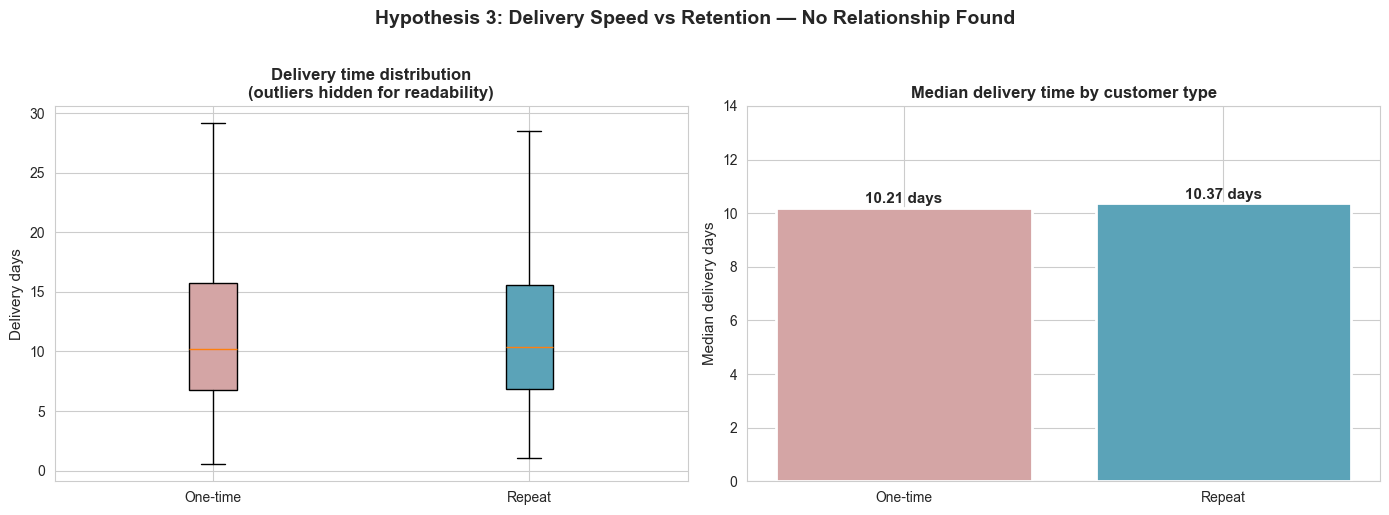

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: Box plot comparing distributions
data_to_plot = [
    first_orders_clean[~first_orders_clean['is_repeat']]['delivery_days'],
    first_orders_clean[first_orders_clean['is_repeat']]['delivery_days']
]
bp = axes[0].boxplot(data_to_plot, labels=['One-time', 'Repeat'],
                      patch_artist=True, showfliers=False)
bp['boxes'][0].set_facecolor('#D4A5A5')
bp['boxes'][1].set_facecolor('#5BA3B8')
axes[0].set_ylabel('Delivery days', fontsize=11)
axes[0].set_title('Delivery time distribution\n(outliers hidden for readability)',
                  fontsize=12, fontweight='bold')

# RIGHT: Bar chart of medians
medians = [one_time_median, repeat_median]
bars = axes[1].bar(['One-time', 'Repeat'], medians,
                    color=['#D4A5A5', '#5BA3B8'], edgecolor='white', linewidth=2)
for bar, val in zip(bars, medians):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                 f'{val:.2f} days', ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Median delivery days', fontsize=11)
axes[1].set_title('Median delivery time by customer type',
                  fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 14)

plt.suptitle('Hypothesis 3: Delivery Speed vs Retention — No Relationship Found',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/h3_delivery_speed.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Filter to customers who actually left a review on their first order
reviewed_first = first_orders_clean.dropna(subset=['review_score']).copy()
print(f"Customers with first-order review: {len(reviewed_first):,}")

# Calculate repeat rate for each review score
repeat_by_score = (
    reviewed_first
    .groupby('review_score')
    .agg(
        total_customers=('customer_unique_id', 'count'),
        repeat_customers=('is_repeat', 'sum')
    )
)
repeat_by_score['repeat_rate_pct'] = (
    repeat_by_score['repeat_customers'] / repeat_by_score['total_customers'] * 100
).round(2)

print("\nRepeat rate by first-order review score:")
print(repeat_by_score)

# The key business question: how much does a good review matter?
rate_5_star = repeat_by_score.loc[5.0, 'repeat_rate_pct']
rate_1_star = repeat_by_score.loc[1.0, 'repeat_rate_pct']
print(f"\n5-star reviewers repeat at: {rate_5_star}%")
print(f"1-star reviewers repeat at: {rate_1_star}%")
print(f"Ratio: 5-star reviewers are {rate_5_star/rate_1_star:.2f}x more likely to repeat")

Customers with first-order review: 92,734

Repeat rate by first-order review score:
              total_customers  repeat_customers  repeat_rate_pct
review_score                                                    
1.0                      9058               246             2.72
1.5                         5                 4            80.00
2.0                      2831                77             2.72
2.5                        15                 7            46.67
3.0                      7669               224             2.92
3.5                        12                10            83.33
4.0                     18354               501             2.73
4.5                        30                25            83.33
5.0                     54760              1685             3.08

5-star reviewers repeat at: 3.08%
1-star reviewers repeat at: 2.72%
Ratio: 5-star reviewers are 1.13x more likely to repeat


Repeat rate by review score (rounded to integers):
                  total_customers  repeat_customers  repeat_rate_pct
review_score_int                                                    
1                            9058               246             2.72
2                            2851                88             3.09
3                            7669               224             2.92
4                           18396               536             2.91
5                           54760              1685             3.08


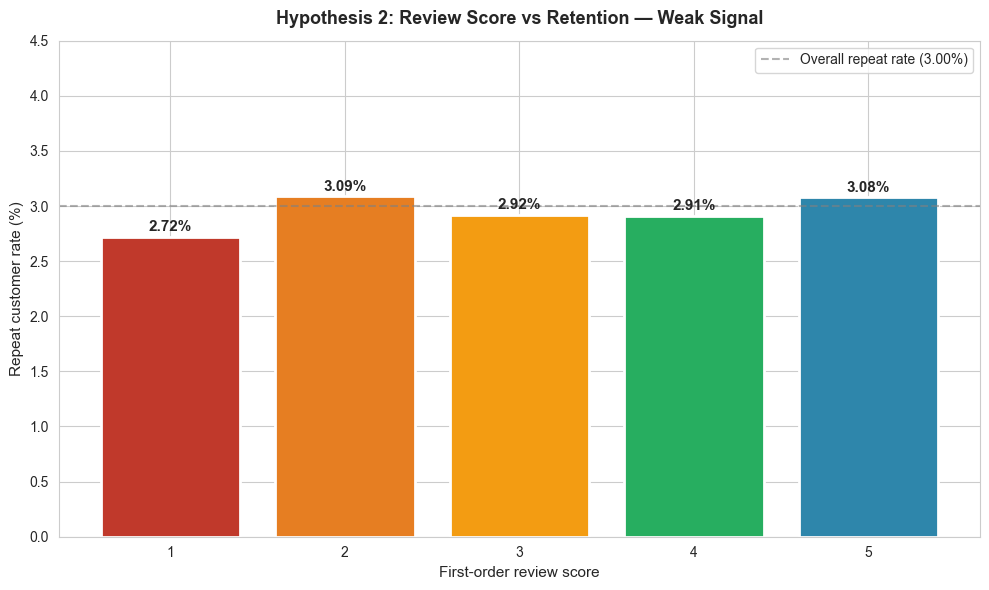

In [6]:
# Round review scores to integers so we have clean 1-5 scale
reviewed_first['review_score_int'] = reviewed_first['review_score'].round().astype(int)

# Recalculate with clean scores
repeat_by_score_clean = (
    reviewed_first
    .groupby('review_score_int')
    .agg(
        total_customers=('customer_unique_id', 'count'),
        repeat_customers=('is_repeat', 'sum')
    )
)
repeat_by_score_clean['repeat_rate_pct'] = (
    repeat_by_score_clean['repeat_customers'] / repeat_by_score_clean['total_customers'] * 100
).round(2)

print("Repeat rate by review score (rounded to integers):")
print(repeat_by_score_clean)

# Visualize
plt.figure(figsize=(10, 6))
bars = plt.bar(
    repeat_by_score_clean.index,
    repeat_by_score_clean['repeat_rate_pct'],
    color=['#C0392B', '#E67E22', '#F39C12', '#27AE60', '#2E86AB'],
    edgecolor='white', linewidth=2
)

for bar, val in zip(bars, repeat_by_score_clean['repeat_rate_pct']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val}%', ha='center', fontsize=11, fontweight='bold')

plt.axhline(y=3.00, color='gray', linestyle='--', alpha=0.6, label='Overall repeat rate (3.00%)')
plt.xlabel('First-order review score', fontsize=11)
plt.ylabel('Repeat customer rate (%)', fontsize=11)
plt.title('Hypothesis 2: Review Score vs Retention — Weak Signal',
          fontsize=13, fontweight='bold', pad=12)
plt.ylim(0, 4.5)
plt.legend()
plt.tight_layout()
plt.savefig('../reports/h2_review_score.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Compute repeat rate by product category (of first order)
category_retention = (
    first_orders_clean
    .dropna(subset=['product_category_name_english'])
    .groupby('product_category_name_english')
    .agg(
        total_customers=('customer_unique_id', 'count'),
        repeat_customers=('is_repeat', 'sum')
    )
)

category_retention['repeat_rate_pct'] = (
    category_retention['repeat_customers'] / category_retention['total_customers'] * 100
).round(2)

# Only keep categories with enough data to be meaningful (>= 500 customers)
category_retention_filtered = category_retention[category_retention['total_customers'] >= 500].copy()
category_retention_filtered = category_retention_filtered.sort_values('repeat_rate_pct', ascending=False)

print(f"Categories with 500+ first-time customers: {len(category_retention_filtered)}")
print(f"\nTop 10 categories by repeat rate:")
print(category_retention_filtered.head(10))
print(f"\nBottom 10 categories by repeat rate:")
print(category_retention_filtered.tail(10))

Categories with 500+ first-time customers: 25

Top 10 categories by repeat rate:
                               total_customers  repeat_customers  \
product_category_name_english                                      
home_appliances                            675                59   
fashion_bags_accessories                  1693                98   
furniture_decor                           5917               273   
bed_bath_table                            8746               389   
sports_leisure                            7196               271   
garden_tools                              3329                98   
perfumery                                 2990                86   
pet_shop                                  1631                47   
computers_accessories                     6299               181   
health_beauty                             8357               227   

                               repeat_rate_pct  
product_category_name_english                   
home

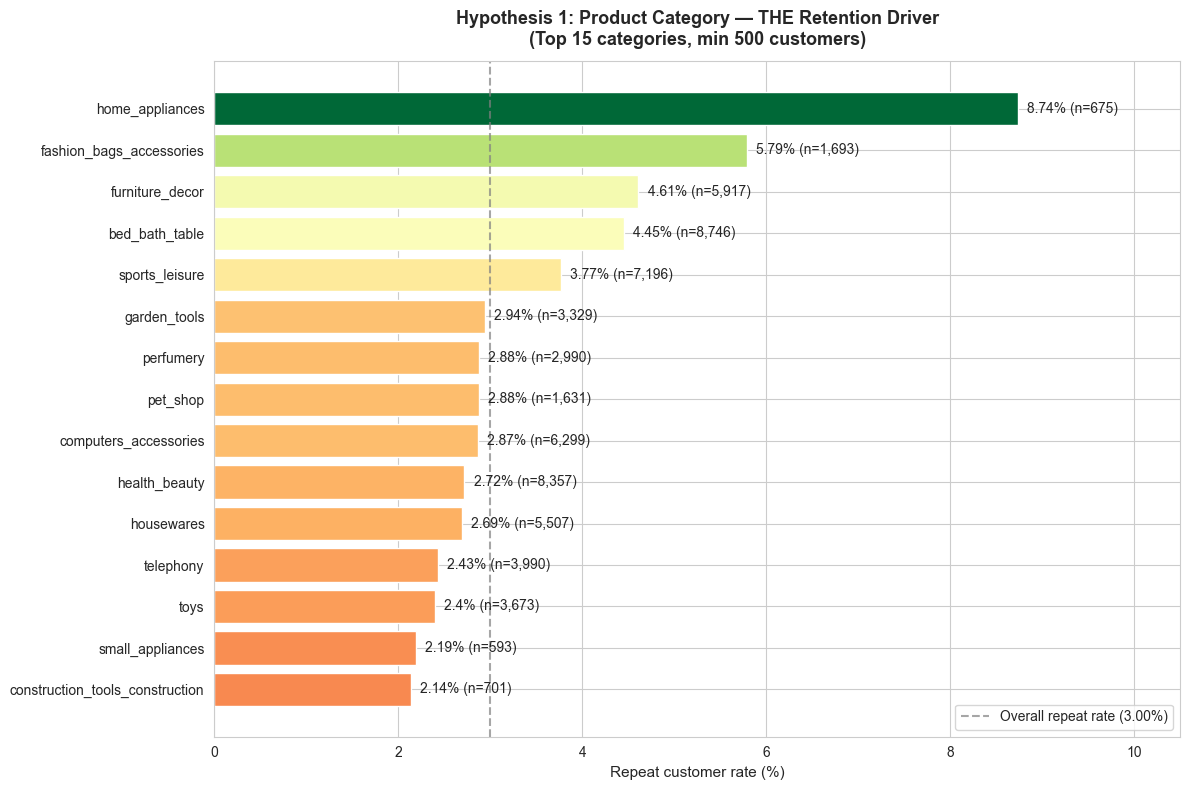

In [8]:
# Get top 15 categories for a cleaner chart
top_15 = category_retention_filtered.head(15)

fig, ax = plt.subplots(figsize=(12, 8))

# Color gradient based on repeat rate
colors = plt.cm.RdYlGn(top_15['repeat_rate_pct'] / top_15['repeat_rate_pct'].max())

bars = ax.barh(top_15.index, top_15['repeat_rate_pct'], color=colors, edgecolor='white')

# Annotate each bar
for bar, val, count in zip(bars, top_15['repeat_rate_pct'], top_15['total_customers']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val}% (n={count:,})', va='center', fontsize=10)

# Reference line: overall repeat rate
ax.axvline(x=3.0, color='gray', linestyle='--', alpha=0.7, label='Overall repeat rate (3.00%)')

ax.set_xlabel('Repeat customer rate (%)', fontsize=11)
ax.set_title('Hypothesis 1: Product Category — THE Retention Driver\n(Top 15 categories, min 500 customers)',
             fontsize=13, fontweight='bold', pad=12)
ax.invert_yaxis()
ax.legend(loc='lower right')
ax.set_xlim(0, 10.5)
plt.tight_layout()
plt.savefig('../reports/h1_product_category.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Create spend buckets based on first-order value
# Use quintiles (5 equal-size groups)
first_orders_clean['spend_bucket'] = pd.qcut(
    first_orders_clean['price'],
    q=5,
    labels=['Very Low (bottom 20%)', 'Low', 'Medium', 'High', 'Very High (top 20%)']
)

# Calculate repeat rate per bucket
spend_retention = (
    first_orders_clean
    .groupby('spend_bucket', observed=True)
    .agg(
        total_customers=('customer_unique_id', 'count'),
        repeat_customers=('is_repeat', 'sum'),
        avg_first_order_value=('price', 'mean'),
        min_value=('price', 'min'),
        max_value=('price', 'max')
    )
)

spend_retention['repeat_rate_pct'] = (
    spend_retention['repeat_customers'] / spend_retention['total_customers'] * 100
).round(2)

spend_retention[['avg_first_order_value', 'min_value', 'max_value']] = spend_retention[['avg_first_order_value', 'min_value', 'max_value']].round(2)

print("Repeat rate by first-order spend bucket:")
print(spend_retention)

# Compare extremes
low_rate = spend_retention.loc['Very Low (bottom 20%)', 'repeat_rate_pct']
high_rate = spend_retention.loc['Very High (top 20%)', 'repeat_rate_pct']
print(f"\nBottom 20% spenders repeat at: {low_rate}%")
print(f"Top 20% spenders repeat at:    {high_rate}%")
print(f"Ratio: {high_rate/low_rate:.2f}x")

Repeat rate by first-order spend bucket:
                       total_customers  repeat_customers  \
spend_bucket                                               
Very Low (bottom 20%)            18842               636   
Low                              19138               617   
Medium                           18188               601   
High                             18529               454   
Very High (top 20%)              18653               493   

                       avg_first_order_value  min_value  max_value  \
spend_bucket                                                         
Very Low (bottom 20%)                  23.62       0.85       35.0   
Low                                    48.88      35.06       59.9   
Medium                                 79.48      59.91       99.0   
High                                  124.89      99.06      159.0   
Very High (top 20%)                   354.01     159.04     6735.0   

                       repeat_rate_pct  
spend_

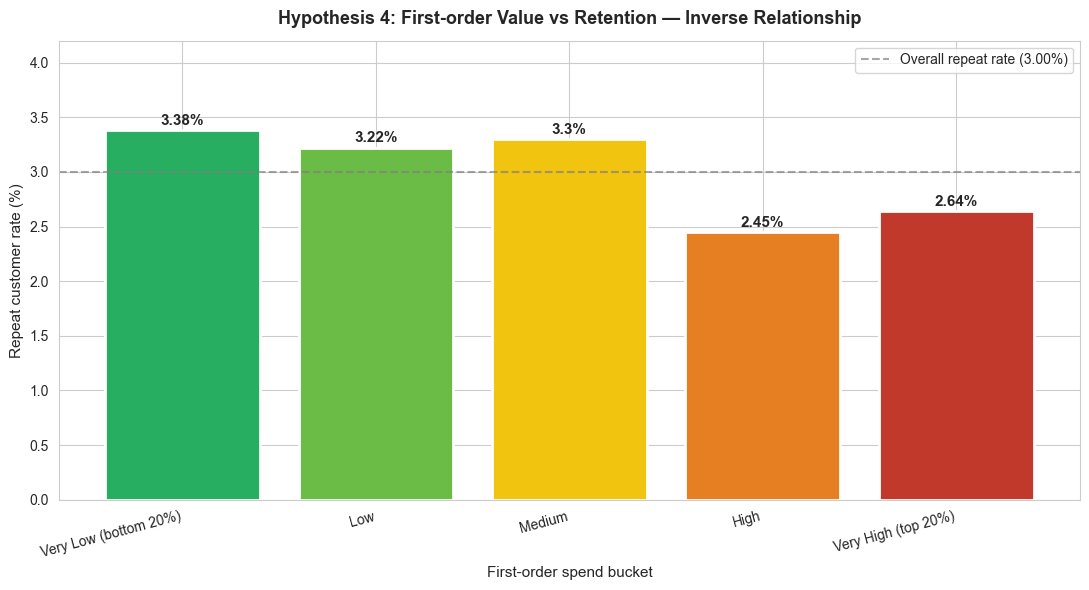

In [10]:
# Plot: spend bucket vs repeat rate
fig, ax = plt.subplots(figsize=(11, 6))

bucket_order = ['Very Low (bottom 20%)', 'Low', 'Medium', 'High', 'Very High (top 20%)']
rates = [spend_retention.loc[b, 'repeat_rate_pct'] for b in bucket_order]

# Color gradient: good-to-bad (inverse relationship, so high rate = green, low = red)
colors = ['#27AE60', '#6BBC47', '#F1C40F', '#E67E22', '#C0392B']

bars = ax.bar(bucket_order, rates, color=colors, edgecolor='white', linewidth=2)

for bar, val in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val}%', ha='center', fontsize=11, fontweight='bold')

ax.axhline(y=3.0, color='gray', linestyle='--', alpha=0.7, label='Overall repeat rate (3.00%)')
ax.set_ylabel('Repeat customer rate (%)', fontsize=11)
ax.set_xlabel('First-order spend bucket', fontsize=11)
ax.set_title('Hypothesis 4: First-order Value vs Retention — Inverse Relationship',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylim(0, 4.2)
ax.legend()
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('../reports/h4_first_order_value.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Save the per-customer retention analysis base table
first_orders_clean.to_parquet('../data/processed/first_orders_analysis.parquet', index=False)

# Save each hypothesis result
category_retention_filtered.to_csv('../data/processed/h1_category_retention.csv')
repeat_by_score_clean.to_csv('../data/processed/h2_review_retention.csv')
spend_retention.to_csv('../data/processed/h4_spend_retention.csv')

print("Saved retention driver analysis:")
print("  data/processed/first_orders_analysis.parquet")
print("  data/processed/h1_category_retention.csv")
print("  data/processed/h2_review_retention.csv")
print("  data/processed/h4_spend_retention.csv")

Saved retention driver analysis:
  data/processed/first_orders_analysis.parquet
  data/processed/h1_category_retention.csv
  data/processed/h2_review_retention.csv
  data/processed/h4_spend_retention.csv
